# Model Training Analysis
**UPI Transaction Analytics & Risk Monitoring Platform**

Inspects the trained models: cross-validation scores, threshold analysis, and latency benchmarks.

> Run `main.py` first to generate trained models in `models/`

In [1]:
%pip install --quiet scikit-learn joblib pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import time

%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': '#0D1117', 'axes.facecolor': '#161B22',
    'axes.edgecolor': '#30363D',   'axes.labelcolor': '#C9D1D9',
    'xtick.color': '#8B949E',      'ytick.color': '#8B949E',
    'text.color': '#C9D1D9',       'grid.color': '#21262D',
    'grid.alpha': 0.6,             'legend.facecolor': '#161B22',
    'legend.edgecolor': '#30363D', 'font.family': 'DejaVu Sans',
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
})
PALETTE = {
    'fraud': '#FF4757', 'legit': '#2ED573', 'medium': '#FFA502',
    'accent': '#1E90FF', 'purple': '#A855F7', 'teal': '#00BCD4',
    'bg_dark': '#0D1117', 'bg_card': '#161B22', 'border': '#30363D', 'text_muted': '#8B949E',
}

FEATURE_COLS = joblib.load('../models/feature_cols.pkl')
rf_model     = joblib.load('../models/random_forest.pkl')

df_feat = pd.read_csv('../data/processed/featured_data.csv')
df_sorted = df_feat.sort_values('step')
split_idx = int(len(df_sorted) * 0.80)
X_sorted  = df_sorted[FEATURE_COLS].fillna(0)
y_sorted  = df_sorted['isFraud']
X_train, X_test = X_sorted.iloc[:split_idx], X_sorted.iloc[split_idx:]
y_train, y_test = y_sorted.iloc[:split_idx], y_sorted.iloc[split_idx:]

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Model: {rf_model.__class__.__name__}  |  Trees: {rf_model.n_estimators}")

Train: 35,531  |  Test: 8,883
Model: RandomForestClassifier  |  Trees: 300


## 1. Cross-Validation ROC-AUC Scores

Running 5-fold cross-validation (on 8k train subset)...
CV ROC-AUC: 0.9616 +/- 0.0767


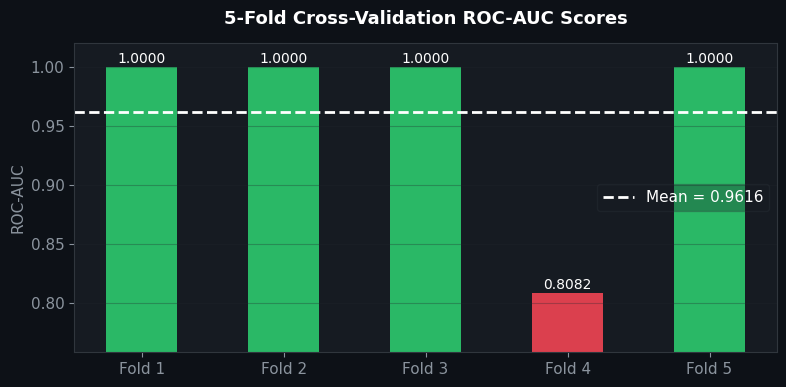

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_cv = X_train.head(min(8000, len(X_train)))
y_cv = y_train.head(min(8000, len(y_train)))

print("Running 5-fold cross-validation (on 8k train subset)...")
cv_scores = cross_val_score(rf_model, X_cv, y_cv, cv=skf, scoring='roc_auc', n_jobs=-1)
print(f"CV ROC-AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4), facecolor=PALETTE['bg_dark'])
fold_colors = [PALETTE['fraud'] if s < cv_scores.mean() else PALETTE['legit'] for s in cv_scores]
bars = ax.bar([f'Fold {i+1}' for i in range(len(cv_scores))], cv_scores,
              color=fold_colors, alpha=0.85, width=0.5)
ax.axhline(cv_scores.mean(), color='white', linestyle='--', linewidth=2,
           label=f'Mean = {cv_scores.mean():.4f}')
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, color='white')
ax.set_title('5-Fold Cross-Validation ROC-AUC Scores', color='white', pad=14)
ax.set_ylabel('ROC-AUC', color=PALETTE['text_muted'])
ax.set_ylim(max(0, cv_scores.min()-0.05), 1.02)
ax.legend(labelcolor='white', framealpha=0.3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Threshold Analysis — Precision vs Recall Trade-off

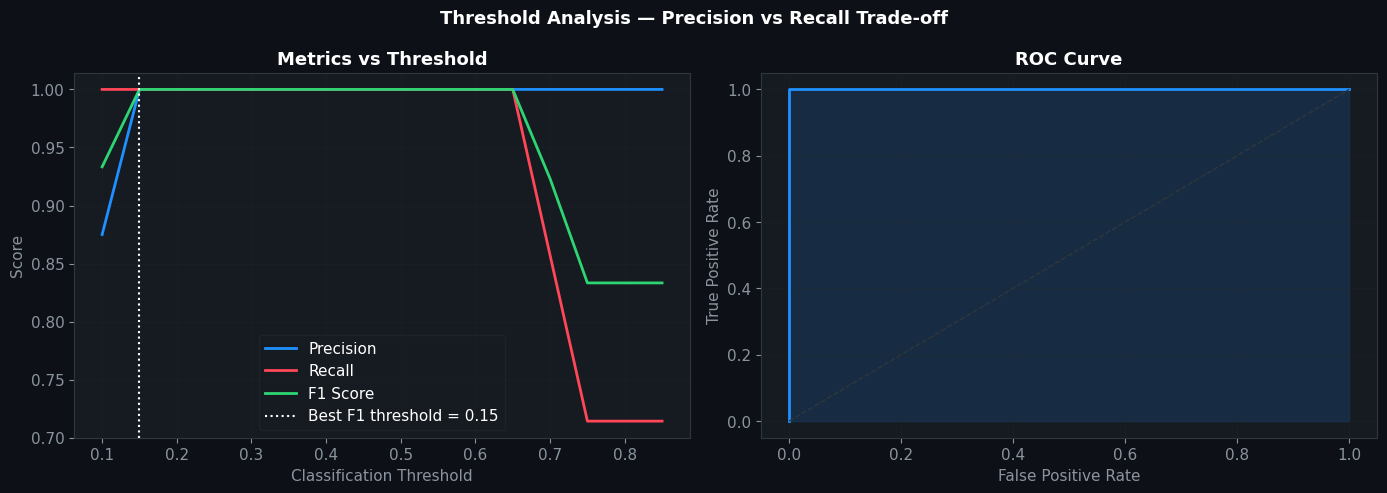


Best threshold by F1: 0.15  (Precision=1.0000, Recall=1.0000, F1=1.0000)


In [4]:
from sklearn.metrics import roc_curve, precision_score, recall_score, f1_score

y_prob_train = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_train)

thresholds_to_test = np.arange(0.1, 0.9, 0.05)
records = []
for t in thresholds_to_test:
    y_pred_t = (y_prob_train >= t).astype(int)
    records.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test, y_pred_t, zero_division=0),
        'fpr':       (y_pred_t[y_test==0].sum() / max((y_test==0).sum(), 1)),
    })
df_thresh = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=PALETTE['bg_dark'])
fig.suptitle('Threshold Analysis — Precision vs Recall Trade-off', fontsize=13, fontweight='bold', color='white')

ax = axes[0]
ax.plot(df_thresh['threshold'], df_thresh['precision'], color=PALETTE['accent'], linewidth=2, label='Precision')
ax.plot(df_thresh['threshold'], df_thresh['recall'],    color=PALETTE['fraud'],  linewidth=2, label='Recall')
ax.plot(df_thresh['threshold'], df_thresh['f1'],        color=PALETTE['legit'],  linewidth=2, label='F1 Score')
best_f1_row = df_thresh.loc[df_thresh['f1'].idxmax()]
ax.axvline(best_f1_row['threshold'], color='white', linestyle=':', linewidth=1.5,
           label=f"Best F1 threshold = {best_f1_row['threshold']:.2f}")
ax.set_title('Metrics vs Threshold', color='white')
ax.set_xlabel('Classification Threshold', color=PALETTE['text_muted'])
ax.set_ylabel('Score', color=PALETTE['text_muted'])
ax.legend(labelcolor='white', framealpha=0.3)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(fpr, tpr, color=PALETTE['accent'], linewidth=2)
ax.fill_between(fpr, tpr, alpha=0.15, color=PALETTE['accent'])
ax.plot([0,1],[0,1],'--',color=PALETTE['border'],linewidth=1)
ax.set_title('ROC Curve', color='white')
ax.set_xlabel('False Positive Rate', color=PALETTE['text_muted'])
ax.set_ylabel('True Positive Rate', color=PALETTE['text_muted'])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"\nBest threshold by F1: {best_f1_row['threshold']:.2f}  "
      f"(Precision={best_f1_row['precision']:.4f}, Recall={best_f1_row['recall']:.4f}, F1={best_f1_row['f1']:.4f})")

## 3. Risk Engine Latency Benchmark

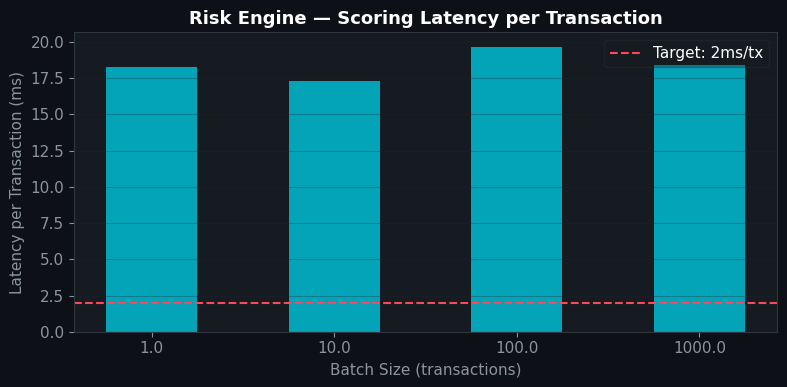

   n     total_ms  per_tx_ms
   1    18.295050  18.295050
  10   173.199892  17.319989
 100  1968.692780  19.686928
1000 18423.343897  18.423344


In [5]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

# Score latency benchmark
from src.risk_engine import UPIRiskEngine

engine = UPIRiskEngine(
    ml_model  = rf_model,
    iso_model = joblib.load('../models/isolation_forest.pkl'),
    scaler    = joblib.load('../models/scaler.pkl'),
    feat_cols = FEATURE_COLS,
)

sample_sizes = [1, 10, 100, 1000]
latencies = []
for n in sample_sizes:
    subset = X_test.head(n)
    t0 = time.time()
    engine.score_dataframe(subset)
    elapsed = (time.time() - t0) * 1000
    latencies.append({'n': n, 'total_ms': elapsed, 'per_tx_ms': elapsed / n})
df_lat = pd.DataFrame(latencies)

fig, ax = plt.subplots(figsize=(8, 4), facecolor=PALETTE['bg_dark'])
ax.bar([str(r['n']) for _, r in df_lat.iterrows()], df_lat['per_tx_ms'],
       color=PALETTE['teal'], alpha=0.85, width=0.5)
ax.axhline(2, color=PALETTE['fraud'], linestyle='--', linewidth=1.5, label='Target: 2ms/tx')
ax.set_title('Risk Engine — Scoring Latency per Transaction', color='white')
ax.set_xlabel('Batch Size (transactions)', color=PALETTE['text_muted'])
ax.set_ylabel('Latency per Transaction (ms)', color=PALETTE['text_muted'])
ax.legend(labelcolor='white', framealpha=0.3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print(df_lat.to_string(index=False))